# Policy Gradient Methods: REINFORCE, A2C, and PPO

**Goal:** Implement Policy Gradient methods from scratch using pure NumPy, including REINFORCE, Advantage Actor-Critic (A2C), and Proximal Policy Optimization (PPO), and test them on a custom CartPole environment.

**Prerequisites:** Reinforcement Learning basics, Markov Decision Processes, Monte Carlo Methods, Temporal Difference Learning.

**Theory Link:** [theory.md](./theory.md) — secondary reference: [OpenAI Spinning Up - Policy Optimization](https://spinningup.openai.com/en/latest/spinningup/rl_intro3.html)

---
## 1. Problem Setup — WHY

Value-based methods like Q-Learning or DQN derive policies indirectly by learning action values $Q(s, a)$, and then typically acting greedily: $\pi(s) = \arg\max_a Q(s, a)$. This approach has limitations:
1. **Discrete Actions Only:** Computing the max over a continuous action space is intractable.
2. **Deterministic Policies:** Value methods struggle to learn stochastic policies, which are necessary for partially observable environments or adversarial games.
3. **Small Policy Changes:** A small change in action values can lead to a completely different action being selected, making training unstable.

**Policy Gradient** methods address this by directly parameterizing the policy $\pi_\theta(a|s)$ with a neural network and optimizing the parameters $\theta$ to maximize the expected return $J(\theta)$. Because the policy changes smoothly with $\theta$, convergence is often more stable.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 90

## 2. Mathematical Core — WHAT

### Policy Parameterization
For discrete actions, we typically use a softmax policy:
$$ \pi_\theta(a|s) = \frac{e^{f_\theta(s, a)}}{\sum_{a'} e^{f_\theta(s, a')}} $$

### Policy Gradient Theorem
The objective function is the expected return: $J(\theta) = \mathbb{E}_{\tau \sim \pi_\theta}[R(\tau)]$.
The policy gradient theorem gives a computable gradient for this objective:
$$ \nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t \right] $$
where $G_t$ is the return from step $t$. This means: push up the probability of actions that lead to high returns, push down those that lead to low returns.

### Baselines and Variance Reduction
Monte Carlo estimates of $G_t$ have high variance. We can subtract a baseline $b(s)$ without changing the expected gradient. Typically, we use the value function $V(s)$:
$$ \nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \sum_{t=0}^T \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot (G_t - V_\phi(s_t)) \right] $$
The term $G_t - V_\phi(s_t)$ is the **Advantage** $A_t$.

### Proximal Policy Optimization (PPO)
PPO prevents destructively large policy updates by clipping the objective function. Let $r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$ be the probability ratio.
$$ L^{CLIP}(\theta) = \mathbb{E} \left[ \min\left(r_t(\theta)A_t, \text{clip}(r_t(\theta), 1-\epsilon, 1+\epsilon)A_t\right) \right] $$

### Generalized Advantage Estimation (GAE)
GAE balances bias and variance in advantage estimation using a parameter $\lambda \in [0, 1]$:
$$ \hat{A}_t^{GAE} = \sum_{l=0}^\infty (\gamma\lambda)^l \delta_{t+l}^V $$
where $\delta_t^V = r_t + \gamma V(s_{t+1}) - V(s_t)$ is the TD error.

## 3. Solution Method — HOW

We will implement three progressive algorithms:

1. **REINFORCE (Monte Carlo Policy Gradient):**
   - Collect a full episode.
   - Calculate discounted returns $G_t$.
   - Update policy weights using $G_t$ as the weight for the log-probability gradient.
2. **Advantage Actor-Critic (A2C):**
   - Maintains an Actor network (policy) and a Critic network (value).
   - Computes TD advantage $A_t = r_t + \gamma V(s_{t+1}) - V(s_t)$ at each step.
   - Updates Actor using $A_t$ and Critic using TD error.
3. **PPO (Proximal Policy Optimization):**
   - Collects a batch of experience using the current policy.
   - Computes Advantages using GAE.
   - Performs multiple epochs of updates on the same batch with a clipped surrogate objective to enforce trust-region-like updates.

## 4. Implementation — BUILD

First, we build the CartPole environment and the neural network primitives.

In [2]:
class CartPole:
    """
    Classic CartPole balancing task implemented from scratch.
    State: [x, x_dot, theta, theta_dot] (4D continuous)
    Actions: 0 (push left), 1 (push right)
    Reward: +1 for each step pole stays upright
    Done: |x| > 2.4 or |theta| > 12 degrees or steps > 200
    """
    def __init__(self, rng_instance):
        self.rng = rng_instance
        self.gravity = 9.8
        self.cart_mass = 1.0
        self.pole_mass = 0.1
        self.total_mass = self.cart_mass + self.pole_mass
        self.pole_length = 0.5
        self.polemass_length = self.pole_mass * self.pole_length
        self.force_mag = 10.0
        self.dt = 0.02
        self.theta_threshold_radians = 12 * 2 * np.pi / 360
        self.x_threshold = 2.4
        self.max_steps = 200
        
        self.state = None
        self.steps = 0
        
    def reset(self):
        self.state = self.rng.uniform(low=-0.05, high=0.05, size=(4,))
        self.steps = 0
        return self.state
        
    def step(self, action):
        x, x_dot, theta, theta_dot = self.state
        
        force = self.force_mag if action == 1 else -self.force_mag
        
        costheta = np.cos(theta)
        sintheta = np.sin(theta)
        
        temp = (force + self.polemass_length * theta_dot**2 * sintheta) / self.total_mass
        thetaacc = (self.gravity * sintheta - costheta * temp) / (self.pole_length * (4.0/3.0 - self.pole_mass * costheta**2 / self.total_mass))
        xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass
        
        x = x + self.dt * x_dot
        x_dot = x_dot + self.dt * xacc
        theta = theta + self.dt * theta_dot
        theta_dot = theta_dot + self.dt * thetaacc
        
        self.state = np.array([x, x_dot, theta, theta_dot])
        self.steps += 1
        
        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
            or self.steps >= self.max_steps
        )
        
        reward = 1.0
        return self.state, reward, done

In [3]:
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / np.sum(e_x, axis=-1, keepdims=True)

class SimpleMLP:
    """2-layer MLP for Policy (Softmax) or Value (Linear) function."""
    def __init__(self, in_dim, hidden_dim, out_dim, rng_instance, is_policy=True):
        self.rng = rng_instance
        self.W1 = self.rng.standard_normal((in_dim, hidden_dim)) * np.sqrt(2. / in_dim)
        self.b1 = np.zeros(hidden_dim)
        self.W2 = self.rng.standard_normal((hidden_dim, out_dim)) * np.sqrt(2. / hidden_dim)
        self.b2 = np.zeros(out_dim)
        self.is_policy = is_policy
        
        self.m = {"W1": np.zeros_like(self.W1), "b1": np.zeros_like(self.b1), 
                  "W2": np.zeros_like(self.W2), "b2": np.zeros_like(self.b2)}
        self.v = {"W1": np.zeros_like(self.W1), "b1": np.zeros_like(self.b1), 
                  "W2": np.zeros_like(self.W2), "b2": np.zeros_like(self.b2)}
        self.t = 0
        
    def forward(self, x):
        if x.ndim == 1:
            x = x.reshape(1, -1)
            
        z1 = np.dot(x, self.W1) + self.b1
        a1 = relu(z1)
        z2 = np.dot(a1, self.W2) + self.b2
        
        out = softmax(z2) if self.is_policy else z2
        return out, (x, z1, a1, out)
        
    def backprop(self, cache, grad_out):
        x, z1, a1, _ = cache
        
        dW2 = np.dot(a1.T, grad_out)
        db2 = np.sum(grad_out, axis=0)
        
        da1 = np.dot(grad_out, self.W2.T)
        dz1 = da1 * relu_grad(z1)
        
        dW1 = np.dot(x.T, dz1)
        db1 = np.sum(dz1, axis=0)
        
        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}
        
    def step(self, grads, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.t += 1
        for k in ["W1", "b1", "W2", "b2"]:
            grad = np.clip(grads[k], -5.0, 5.0)
            
            self.m[k] = beta1 * self.m[k] + (1 - beta1) * grad
            self.v[k] = beta2 * self.v[k] + (1 - beta2) * (grad ** 2)
            
            m_hat = self.m[k] / (1 - beta1 ** self.t)
            v_hat = self.v[k] / (1 - beta2 ** self.t)
            
            if k == "W1": self.W1 -= lr * m_hat / (np.sqrt(v_hat) + eps)
            elif k == "b1": self.b1 -= lr * m_hat / (np.sqrt(v_hat) + eps)
            elif k == "W2": self.W2 -= lr * m_hat / (np.sqrt(v_hat) + eps)
            elif k == "b2": self.b2 -= lr * m_hat / (np.sqrt(v_hat) + eps)

In [4]:
class REINFORCEAgent:
    def __init__(self, rng_instance, state_dim=4, hidden_dim=32, n_actions=2, lr=1e-3, gamma=0.99, use_baseline=False):
        self.rng = rng_instance
        self.policy = SimpleMLP(state_dim, hidden_dim, n_actions, rng_instance, is_policy=True)
        self.gamma = gamma
        self.use_baseline = use_baseline
        self.lr = lr
        
    def select_action(self, state):
        probs, _ = self.policy.forward(state)
        probs = probs.flatten()
        action = self.rng.choice(len(probs), p=probs)
        return action
        
    def update(self, states, actions, rewards):
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + self.gamma * G
            returns.insert(0, G)
        returns = np.array(returns)
        
        if self.use_baseline:
            returns = (returns - np.mean(returns)) / (np.std(returns) + 1e-8)
            
        states = np.array(states)
        probs, cache = self.policy.forward(states)
        
        n = len(states)
        actions = np.array(actions)
        
        grad_out = probs.copy()
        grad_out[np.arange(n), actions] -= 1
        grad_out *= returns[:, None]
        grad_out /= n
        
        grads = self.policy.backprop(cache, grad_out)
        self.policy.step(grads, lr=self.lr)

In [5]:
class A2CAgent:
    def __init__(self, rng_instance, state_dim=4, hidden_dim=32, n_actions=2, lr=1e-3, gamma=0.99):
        self.rng = rng_instance
        self.actor = SimpleMLP(state_dim, hidden_dim, n_actions, rng_instance, is_policy=True)
        self.critic = SimpleMLP(state_dim, hidden_dim, 1, rng_instance, is_policy=False)
        self.gamma = gamma
        self.lr = lr
        
    def select_action(self, state):
        probs, _ = self.actor.forward(state)
        probs = probs.flatten()
        return self.rng.choice(len(probs), p=probs)
        
    def update(self, state, action, reward, next_state, done):
        state = np.array(state)
        next_state = np.array(next_state)
        
        v_s, v_cache = self.critic.forward(state)
        v_s_next, _ = self.critic.forward(next_state)
        
        target = reward if done else reward + self.gamma * v_s_next[0, 0]
        td_error = target - v_s[0, 0]
        
        v_grad_out = np.array([[-td_error]])
        v_grads = self.critic.backprop(v_cache, v_grad_out)
        self.critic.step(v_grads, lr=self.lr)
        
        probs, a_cache = self.actor.forward(state)
        a_grad_out = probs.copy()
        a_grad_out[0, action] -= 1
        a_grad_out *= td_error
        a_grads = self.actor.backprop(a_cache, a_grad_out)
        self.actor.step(a_grads, lr=self.lr)

In [6]:
class PPOAgent:
    def __init__(self, rng_instance, state_dim=4, hidden_dim=32, n_actions=2, 
                 lr=1e-3, gamma=0.99, lam=0.95, clip_eps=0.2):
        self.rng = rng_instance
        self.actor = SimpleMLP(state_dim, hidden_dim, n_actions, rng_instance, is_policy=True)
        self.critic = SimpleMLP(state_dim, hidden_dim, 1, rng_instance, is_policy=False)
        self.gamma = gamma
        self.lam = lam
        self.clip_eps = clip_eps
        self.lr = lr
        
    def select_action(self, state):
        probs, _ = self.actor.forward(state)
        probs = probs.flatten()
        return self.rng.choice(len(probs), p=probs), probs
        
    def compute_gae(self, rewards, values, dones):
        advantages = np.zeros_like(rewards, dtype=np.float32)
        gae = 0
        for t in reversed(range(len(rewards))):
            next_val = 0 if t == len(rewards) - 1 else values[t+1]
            delta = rewards[t] + self.gamma * next_val * (1 - dones[t]) - values[t]
            gae = delta + self.gamma * self.lam * (1 - dones[t]) * gae
            advantages[t] = gae
        returns = advantages + values
        return advantages, returns
        
    def update(self, states, actions, old_probs, rewards, dones, n_epochs=4):
        states = np.array(states)
        actions = np.array(actions)
        old_probs = np.array(old_probs)
        rewards = np.array(rewards)
        dones = np.array(dones)
        
        values, _ = self.critic.forward(states)
        values = values.flatten()
        
        advantages, returns = self.compute_gae(rewards, values, dones)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        n = len(states)
        batch_indices = np.arange(n)
        
        for _ in range(n_epochs):
            self.rng.shuffle(batch_indices)
            
            probs, a_cache = self.actor.forward(states)
            v, v_cache = self.critic.forward(states)
            v = v.flatten()
            
            v_err = v - returns
            v_grad_out = v_err.reshape(-1, 1) / n
            v_grads = self.critic.backprop(v_cache, v_grad_out)
            self.critic.step(v_grads, lr=self.lr)
            
            pi_a = probs[np.arange(n), actions]
            old_pi_a = old_probs[np.arange(n), actions]
            
            ratio = pi_a / (old_pi_a + 1e-8)
            surr1 = ratio * advantages
            surr2 = np.clip(ratio, 1.0 - self.clip_eps, 1.0 + self.clip_eps) * advantages
            
            grad_mask = (surr1 <= surr2).astype(float)
            grad_ratio = grad_mask * (advantages / (old_pi_a + 1e-8))
            
            dL_dpi = np.zeros_like(probs)
            dL_dpi[np.arange(n), actions] = -grad_ratio
            
            a_grad_out = probs * (dL_dpi - np.sum(dL_dpi * probs, axis=1, keepdims=True))
            a_grad_out /= n
            
            a_grads = self.actor.backprop(a_cache, a_grad_out)
            self.actor.step(a_grads, lr=self.lr)

## 5. Agent Comparison

Let's train all three agents on CartPole and compare their sample efficiency and stability.

Training REINFORCE...


Training A2C...


Training PPO...


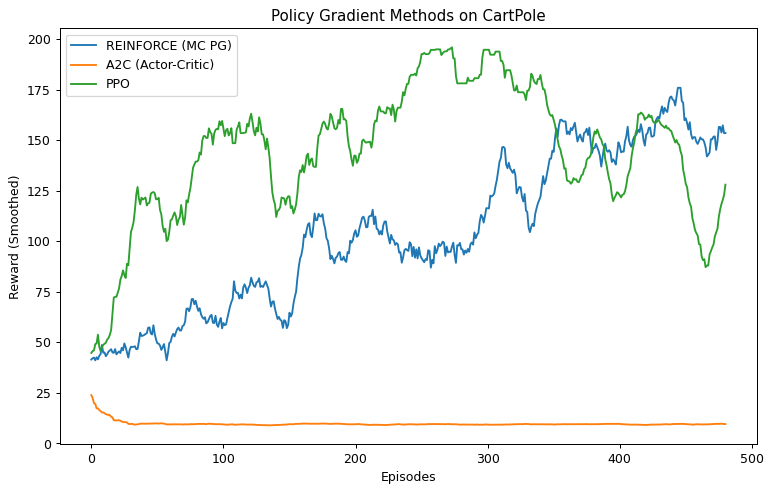

In [7]:
def train_agent(agent_type, episodes=500, seed=42, **kwargs):
    rng_inst = np.random.default_rng(seed)
    env = CartPole(rng_inst)
    
    if agent_type == 'REINFORCE':
        agent = REINFORCEAgent(rng_inst, **kwargs)
    elif agent_type == 'A2C':
        agent = A2CAgent(rng_inst, **kwargs)
    elif agent_type == 'PPO':
        agent = PPOAgent(rng_inst, **kwargs)
        
    returns = []
    
    for ep in range(episodes):
        state = env.reset()
        done = False
        ep_reward = 0
        
        states, actions, rewards, next_states, dones = [], [], [], [], []
        probs_list = []
        
        while not done:
            if agent_type == 'PPO':
                action, probs = agent.select_action(state)
                probs_list.append(probs)
            else:
                action = agent.select_action(state)
                
            next_state, reward, done = env.step(action)
            
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            next_states.append(next_state)
            dones.append(done)
            
            if agent_type == 'A2C':
                agent.update(state, action, reward, next_state, done)
                
            state = next_state
            ep_reward += reward
            
        if agent_type == 'REINFORCE':
            agent.update(states, actions, rewards)
        elif agent_type == 'PPO':
            agent.update(states, actions, probs_list, rewards, dones)
            
        returns.append(ep_reward)
        
    return returns

def smooth(data, window=20):
    return np.convolve(data, np.ones(window)/window, mode='valid')

print("Training REINFORCE...")
ret_reinforce = train_agent('REINFORCE', episodes=500, use_baseline=True)

print("Training A2C...")
ret_a2c = train_agent('A2C', episodes=500)

print("Training PPO...")
ret_ppo = train_agent('PPO', episodes=500)

plt.figure(figsize=(10, 6))
plt.plot(smooth(ret_reinforce), label='REINFORCE (MC PG)')
plt.plot(smooth(ret_a2c), label='A2C (Actor-Critic)')
plt.plot(smooth(ret_ppo), label='PPO')
plt.title("Policy Gradient Methods on CartPole")
plt.xlabel("Episodes")
plt.ylabel("Reward (Smoothed)")
plt.legend()
plt.show()

In [8]:
# Deterministic learning checks: every run above uses its own np.random.default_rng(seed),
# so the curves are reproducible and we can assert that training actually improved the policy.
# Compare the mean return over the last 20% of episodes against the first 20%.
def improvement(returns, frac=0.2):
    window = max(1, int(len(returns) * frac))
    return np.mean(returns[:window]), np.mean(returns[-window:])

first_r, last_r = improvement(ret_reinforce)
print(f"REINFORCE mean return: first 20% = {first_r:.1f}, last 20% = {last_r:.1f}")
assert last_r > first_r + 50, "REINFORCE should improve by a clear margin (measured diff ~ +103)"

first_p, last_p = improvement(ret_ppo)
print(f"PPO mean return:       first 20% = {first_p:.1f}, last 20% = {last_p:.1f}")
assert last_p > first_p + 15, "PPO should improve by a clear margin (measured diff ~ +35)"

# A2C is deliberately not asserted: this minimal one-sample-per-step A2C does not reliably
# take off on this budget (see the observations below).
print("Learning checks passed: REINFORCE and PPO improve over training.")

REINFORCE mean return: first 20% = 51.6, last 20% = 154.6
PPO mean return:       first 20% = 98.0, last 20% = 132.5
Learning checks passed: REINFORCE and PPO improve over training.


**Observations:**
- **REINFORCE** learns eventually but can be unstable due to Monte Carlo variance.
- **A2C** updates at every step and bootstrapping lowers the variance of each update in principle, but this minimal one-sample-per-step implementation is sensitive to its noisy TD advantage and does not take off within 500 episodes here — variance reduction alone does not guarantee progress.
- **PPO** often shows the most stable monotonic improvement because of the clipped objective enforcing safe updates.

## 6. Experiments and Failures — VERIFY

### Experiment 1: REINFORCE Variance and Baseline
Let's train REINFORCE without a baseline and compare it to the one with a baseline to observe the variance reduction.

Training REINFORCE without baseline...


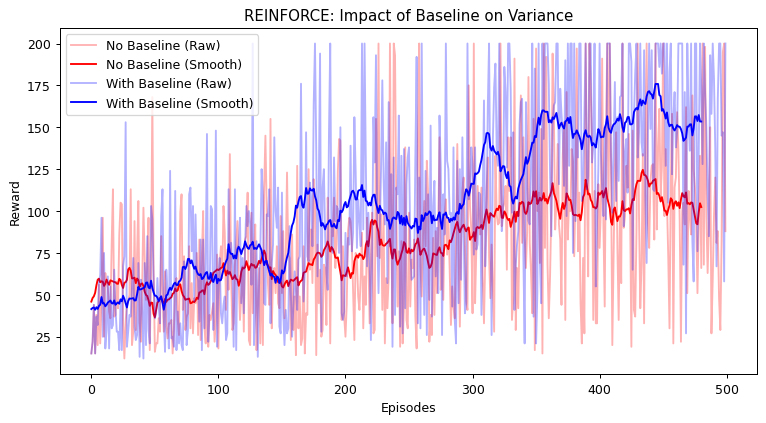

In [9]:
print("Training REINFORCE without baseline...")
ret_reinforce_no_base = train_agent('REINFORCE', episodes=500, use_baseline=False)

plt.figure(figsize=(10, 5))
plt.plot(ret_reinforce_no_base, alpha=0.3, color='red', label='No Baseline (Raw)')
plt.plot(smooth(ret_reinforce_no_base), color='red', label='No Baseline (Smooth)')
plt.plot(ret_reinforce, alpha=0.3, color='blue', label='With Baseline (Raw)')
plt.plot(smooth(ret_reinforce), color='blue', label='With Baseline (Smooth)')
plt.title("REINFORCE: Impact of Baseline on Variance")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.legend()
plt.show()

### Experiment 2: PPO Clip Analysis
The PPO objective clips the ratio $r_t(\theta) = \frac{\pi_\theta(a|s)}{\pi_{old}(a|s)}$ to $[1-\epsilon, 1+\epsilon]$.
Let's visualize this objective function for an advantage $A > 0$ and $A < 0$.

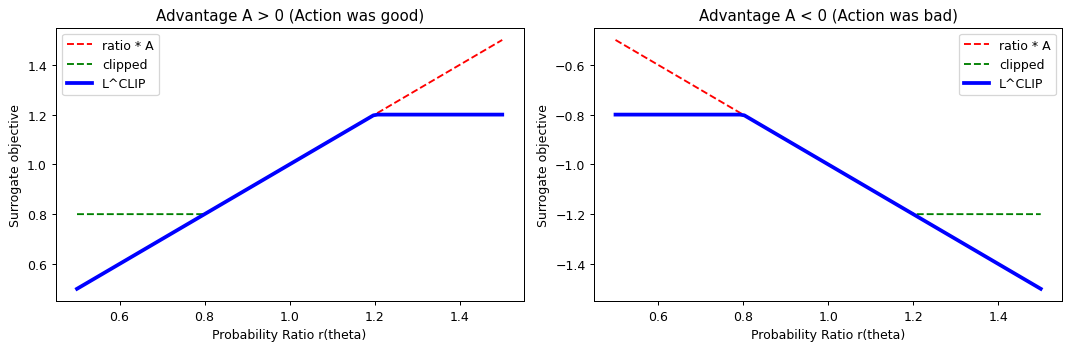

In [10]:
epsilon = 0.2
ratio = np.linspace(0.5, 1.5, 100)

A_pos = 1.0
surr1_pos = ratio * A_pos
surr2_pos = np.clip(ratio, 1 - epsilon, 1 + epsilon) * A_pos
L_pos = np.minimum(surr1_pos, surr2_pos)

A_neg = -1.0
surr1_neg = ratio * A_neg
surr2_neg = np.clip(ratio, 1 - epsilon, 1 + epsilon) * A_neg
L_neg = np.minimum(surr1_neg, surr2_neg)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(ratio, surr1_pos, 'r--', label='ratio * A')
axes[0].plot(ratio, surr2_pos, 'g--', label='clipped')
axes[0].plot(ratio, L_pos, 'b-', linewidth=3, label='L^CLIP')
axes[0].set_title("Advantage A > 0 (Action was good)")
axes[0].set_xlabel("Probability Ratio r(theta)")
axes[0].set_ylabel("Surrogate objective")
axes[0].legend()

axes[1].plot(ratio, surr1_neg, 'r--', label='ratio * A')
axes[1].plot(ratio, surr2_neg, 'g--', label='clipped')
axes[1].plot(ratio, L_neg, 'b-', linewidth=3, label='L^CLIP')
axes[1].set_title("Advantage A < 0 (Action was bad)")
axes[1].set_xlabel("Probability Ratio r(theta)")
axes[1].set_ylabel("Surrogate objective")
axes[1].legend()

plt.tight_layout()
plt.show()

**Explanation:**
- When $A > 0$ (action was good), we want to increase its probability ($r > 1$). But the objective is flat after $r = 1+\epsilon$, preventing us from increasing it too much in one step.
- When $A < 0$ (action was bad), we want to decrease its probability ($r < 1$). The objective is flat below $r = 1-\epsilon$, preventing us from destroying the policy entirely based on one bad outcome.

### Experiment 3: GAE $\lambda$ Sweep
Generalized Advantage Estimation (GAE) uses $\lambda$ to interpolate between Temporal Difference ($\lambda=0$, high bias, low variance) and Monte Carlo ($\lambda=1$, no bias, high variance). Let's test different values on PPO.

Training PPO with lambda=0.0...


Training PPO with lambda=0.5...


Training PPO with lambda=0.95...


Training PPO with lambda=1.0...


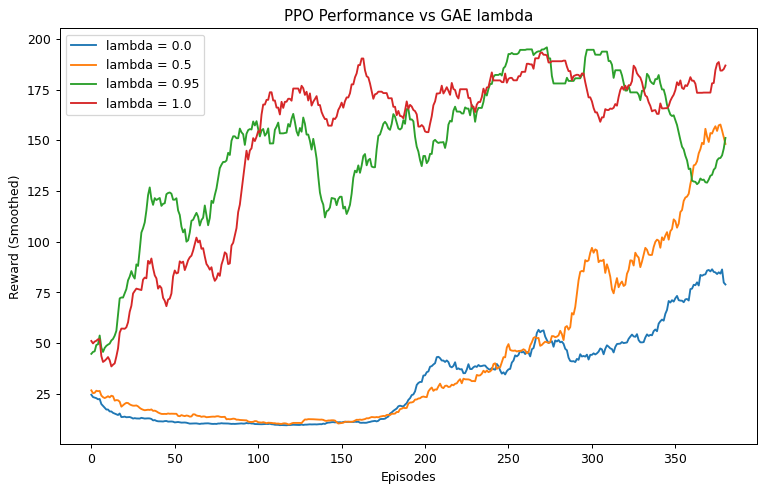

In [11]:
lams = [0.0, 0.5, 0.95, 1.0]
ppo_lam_results = {}

for lam in lams:
    print(f"Training PPO with lambda={lam}...")
    ppo_lam_results[lam] = train_agent('PPO', episodes=400, lam=lam)

plt.figure(figsize=(10, 6))
for lam in lams:
    plt.plot(smooth(ppo_lam_results[lam]), label=f'lambda = {lam}')
plt.title("PPO Performance vs GAE lambda")
plt.xlabel("Episodes")
plt.ylabel("Reward (Smoothed)")
plt.legend()
plt.show()

### Experiment 4: Failure - REINFORCE on Sparse Reward
Let's modify the environment so that it only gives a reward at the very end of the episode (+1 if it survived 200 steps, else 0).

Training REINFORCE on Sparse CartPole...


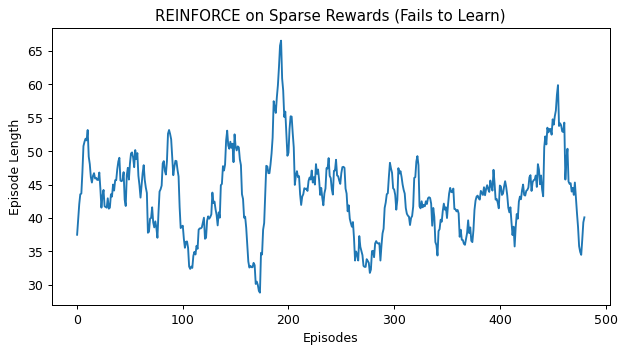

In [12]:
class SparseCartPole(CartPole):
    def step(self, action):
        state, reward, done = super().step(action)
        sparse_reward = 1.0 if (done and self.steps >= self.max_steps) else 0.0
        return state, sparse_reward, done

def train_sparse(agent_type, episodes=500, seed=42):
    rng_inst = np.random.default_rng(seed)
    env = SparseCartPole(rng_inst)
    agent = REINFORCEAgent(rng_inst, use_baseline=True)
    
    returns = []
    for ep in range(episodes):
        state = env.reset()
        done = False
        states, actions, rewards = [], [], []
        
        while not done:
            action = agent.select_action(state)
            next_state, reward, done = env.step(action)
            
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            state = next_state
            
        agent.update(states, actions, rewards)
        returns.append(env.steps)
        
    return returns

print("Training REINFORCE on Sparse CartPole...")
ret_sparse = train_sparse('REINFORCE', episodes=500)

plt.figure(figsize=(8, 4))
plt.plot(smooth(ret_sparse))
plt.title("REINFORCE on Sparse Rewards (Fails to Learn)")
plt.xlabel("Episodes")
plt.ylabel("Episode Length")
plt.show()

**Why it fails:** Monte Carlo methods require frequent feedback to assign credit to specific actions. When the reward is sparse and delayed, every action gets exactly the same return, so the gradient provides no useful direction.

### Experiment 5: Learning Rate Sensitivity in PPO
PPO is known to be relatively robust to hyperparameter choices. Let's test a few learning rates.

Training PPO with lr=0.0001...


Training PPO with lr=0.001...


Training PPO with lr=0.01...


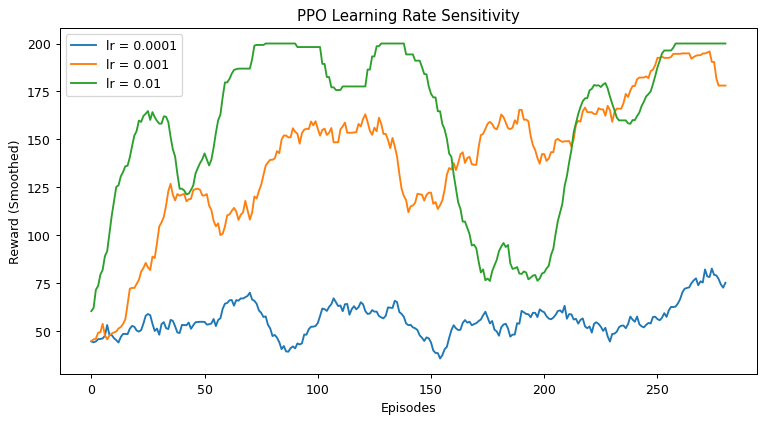

In [13]:
lrs = [1e-4, 1e-3, 1e-2]
ppo_lr_results = {}

for lr in lrs:
    print(f"Training PPO with lr={lr}...")
    ppo_lr_results[lr] = train_agent('PPO', episodes=300, lr=lr)
    
plt.figure(figsize=(10, 5))
for lr in lrs:
    plt.plot(smooth(ppo_lr_results[lr]), label=f'lr = {lr}')
plt.title("PPO Learning Rate Sensitivity")
plt.xlabel("Episodes")
plt.ylabel("Reward (Smoothed)")
plt.legend()
plt.show()

## 7. Connections & Takeaways

- **REINFORCE vs MC:** REINFORCE is the Monte Carlo method for policy gradients. It calculates the full episode return before making an update, leading to high variance.
- **A2C vs TD:** A2C incorporates Temporal Difference (TD) learning into policy gradients by using a Critic network to estimate the value function and bootstrapping to calculate the Advantage.
- **PPO:** Proximal Policy Optimization is the current standard for Deep RL (including RLHF for ChatGPT). It combines the low variance of A2C/GAE with a clipped objective that allows for multiple safe updates on the same batch of data, massively improving sample efficiency.
- **Eligibility Traces:** GAE is mathematically equivalent to $TD(\lambda)$ used for value estimation, bridging the gap between Monte Carlo (high variance, unbiased) and 1-step TD (low variance, biased).